In [1]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    num01 : int
    num02 : int
    final : int
    operation: str

In [3]:
def add_node(state: AgentState) -> AgentState:
    """The first add node"""
    state['final'] = state['num01'] + state['num02']
    return state

def subtract_node(state: AgentState) -> AgentState:
    """The first subtract node"""
    state['final'] = state['num01'] - state['num02']
    return state
def add_node02(state: AgentState) -> AgentState:
    """The second add node"""
    state['final'] = state['num01'] + state['num02']
    return state

def subtract_node02(state: AgentState) -> AgentState:
    """The second subtract node"""
    state['final'] = state['num01'] - state['num02']
    return state

def condition(state:AgentState) -> AgentState:
    if state['operation'] == "+":
     return "add_node"
    elif state['operation'] == "-":
        return "subtract_node"

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("add_node" , add_node)
graph.add_node("subtract_node", subtract_node)


graph.add_node("router", lambda state:state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    condition,
    {
        "add_node" : "add_node",
        "subtract_node" : "subtract_node"
    }

)
graph.add_edge(START, "add_node")
graph.add_edge("add_node", "subtract_node")
# graph.add_edge("subtract_node", "router02")


graph.add_node("add_node02", add_node02)
graph.add_node("subtract_node02", subtract_node02)



graph.add_node("router02", lambda state:state)

graph.add_edge(START, "router02")
graph.add_conditional_edges(
    "router02",
    condition,
    {
        "add_node02" : "add_node02",
        "subtract_node02" : "subtract_node02"
    }

)
graph.add_edge("add_node02",END)
graph.add_edge("subtract_node02", END)

app = graph.compile()

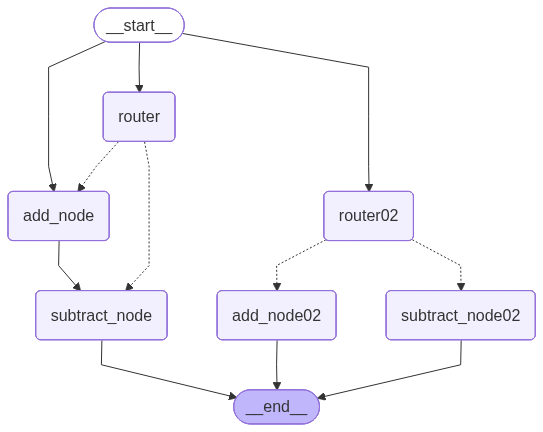

In [12]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))